In [23]:
from langgraph.graph import StateGraph,START,END,add_messages
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from typing import TypedDict,List,Literal
from pydantic import BaseModel,Field
from dotenv import load_dotenv

In [24]:
load_dotenv()

model = ChatOpenAI(model="gpt-4o-mini", temperature=0)  

In [25]:
loader1 = PyPDFLoader('Documents\Company_Policies.pdf')
loader2 = PyPDFLoader('Documents\Company_Profile.pdf')
loader3 = PyPDFLoader('Documents\Product_and_Pricing.pdf')

docs = loader1.load() + loader2.load() + loader3.load()

len(docs)

8

In [26]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size = 600,
    chunk_overlap = 150
)

chunks = splitter.split_documents(docs)

len(chunks)

16

In [27]:
embedding = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = FAISS.from_documents(
    embedding=embedding,
    documents=chunks
)

retriever = vector_store.as_retriever(
    search_type = 'mmr',
    search_kwargs = {'k':4}
)

In [28]:
class RagState(TypedDict):

    question : str
    need_retrieval : bool
    document : List[Document]
    relevant_docs : List[Document]
    context : str
    answer : str

    is_sup : Literal["fully_supported", "partially_supported", "no_support"]
    evidence : List[str]

In [29]:
# decide_retrieval

class RetrievalDecision(BaseModel):

    should_retrieve : bool = Field(...,description="True if external documents are needed to answer reliably, else False.")

template_retrieval = ChatPromptTemplate([
    ('system',"You decide whether retrieval is needed.\n"
        "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{ \"should_retrieve\": \"boolean\" }}\n\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."),
    ('human',"Question : {question}")
        ],
        input_variables = ['question']
        )

def decide_retrieval(state:RagState)->dict:

    question = state['question']

    model_with_structure_retrieval = model.with_structured_output(RetrievalDecision)

    chain_retrieval = template_retrieval | model_with_structure_retrieval

    decision : RetrievalDecision = chain_retrieval.invoke({'question':question})

    print("decide_retrieval : ",decision)

    return {'need_retrieval':decision.should_retrieve}

In [30]:
# generate_direct

template_generate = ChatPromptTemplate([
    ('system',"Answer the question using your model parametric knowledge.\n"
            "Do NOT assume access to external documents.\n"),
    ('human',"Question : {question}")
],
input_variables = ['question']
)

def generate_direct(state:RagState)->dict:

    question = state['question']

    chain_generate = template_generate | model

    response = chain_generate.invoke({'question':question})

    print("generate_direct : ",response)

    return {'answer' : response.content}

In [31]:
# retrieve

def retrieve(state:RagState)->dict:
    
    question = state['question']

    response = retriever.invoke(question)

    print("retrieve : ",response)

    return {'document':response}

In [32]:
# is_relevant

class RelevantDecision(BaseModel):

    is_relevant : bool = Field(...,description="True if the document helps answer the question, else False.")
    
template_relevant = ChatPromptTemplate([
    ('system',"You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."),
    ('human',"Question : \n {question} \n Documents : \n {document} \n")
],
input_variables = ['question','document']
)

model_with_structure_relevant = model.with_structured_output(RelevantDecision)

chain_relevant = template_relevant | model_with_structure_relevant

def is_relevant(state : RagState)->dict:
    
    question = state['question']

    documents = state['document']

    relevant_docs = []

    for document in documents:
        decision : RelevantDecision = chain_relevant.invoke({'question':question,'document':document.page_content})

        if decision.is_relevant:
            relevant_docs.append(document)

    return {'relevant_docs':relevant_docs}

In [33]:
# route_decision

def route_decision(state : RagState)->Literal['generate_direct','retrieve']:

    need_retrieval = state['need_retrieval']

    if need_retrieval:
        return 'retrieve'
    else:
        return 'generate_direct'

In [34]:
# generate_from_context

template_generate_from_context = ChatPromptTemplate([
    ('system',"You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"),
    ('human',"Question : \n {question} \n Context : {context}\n")
],
input_variables = ['question','context']
)

chain_generate_from_context = template_generate_from_context | model

def generate_from_context(state:RagState)->dict:

    question = state['question']

    relevant_docs = state['relevant_docs']

    context = "\n -- \n".join(document.page_content for document in relevant_docs)

    if not context:
        return {'answer':'No relevant documents found','context':''}
    
    response = chain_generate_from_context.invoke({'question':question,'context':context})

    return {'answer':response.content,'context':context}

In [35]:
# no_relevant_docs

def no_relevant_docs(state : RagState)->dict:
    return {'answer':'No relevant docs from','context':''}

In [36]:
def conditional_branch(state:RagState)->dict:

    relevant_docs = state.get('relevant_docs',[])

    if relevant_docs and len(relevant_docs)>0:
        return 'generate_from_context'
    else:
        return 'no_relevant_docs'

In [37]:
# is_sup

class isSupDecision(BaseModel):

    is_sup : Literal["fully_supported", "partially_supported", "no_support"]
    evidence : List[str]

template_is_sup = ChatPromptTemplate([
    ('system',"You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."),
    ('human',"Question : {question}\nAnswer : {answer}\nContext : {context}")
],
input_variables = ['question','answer','context']
)

model_with_structure_is_sup = model.with_structured_output(isSupDecision)

chain_is_sup = template_is_sup | model_with_structure_is_sup

def is_sup(state:RagState)->dict:

    question = state['question']

    answer = state['answer']

    context = state['context']

    decision : isSupDecision = chain_is_sup.invoke({'question':question,'answer':answer,'context':context})

    return {'is_sup':decision.is_sup,'evidence':decision.evidence}

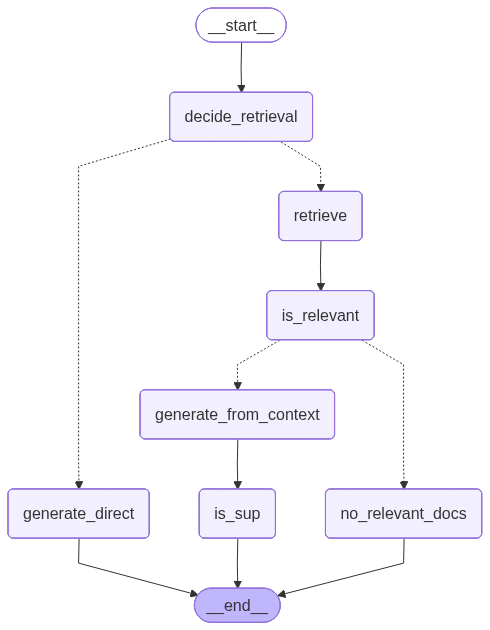

In [38]:
graph = StateGraph(RagState)

graph.add_node('decide_retrieval',decide_retrieval)
graph.add_node('generate_direct',generate_direct)
graph.add_node('retrieve',retrieve)
graph.add_node('is_relevant',is_relevant)
graph.add_node('generate_from_context',generate_from_context)
graph.add_node('no_relevant_docs',no_relevant_docs)
graph.add_node('is_sup',is_sup)

graph.add_edge(START,'decide_retrieval')
graph.add_conditional_edges('decide_retrieval',route_decision,{'generate_direct':'generate_direct','retrieve':'retrieve'})
graph.add_edge('retrieve','is_relevant')
graph.add_conditional_edges('is_relevant',conditional_branch,{'generate_from_context':'generate_from_context','no_relevant_docs':'no_relevant_docs'})
graph.add_edge('generate_from_context','is_sup')
graph.add_edge('is_sup',END)
graph.add_edge('no_relevant_docs',END)
graph.add_edge('generate_direct',END)

chatbot = graph.compile()

chatbot

In [43]:
result = chatbot.invoke({'question':'Do NexaAI plans include a free trial? If yes, how many days?'})

decide_retrieval :  should_retrieve=True
retrieve :  [Document(id='943740a1-37ee-41a5-a55d-7973b04e1242', metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:10:37+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:10:37+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'Documents\\Product_and_Pricing.pdf', 'total_pages': 4, 'page': 2, 'page_label': '3'}, page_content='Pricing & Plans\nNexaAI pricing is based on the number of active users and selected product modules. All plans\ninclude standard security updates and product enhancements.\nStarter Plan\nDesigned for small teams and early-stage adoption.\n\x7f\nPrice: ■2,499 per user per month\n\x7f\nAccess to NexaChat core features\n\x7f\nUp to 5,000 queries per month\n\x7f\nEmail-based customer support\n\x7f\nShared cloud infrastructure\nGrowth Plan\nBest suited for growing teams requiring deeper in

In [44]:
print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("document", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("is_sup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 0
issup: None
evidence: None
answer: No relevant docs from
